# 05 · 활성 사용자 EDA — DAU·WAU·MAU와 세그먼트

**범위:** GA4에서 처음 관측된 2026-07-27부터 완전한 일별 export가 존재하는 2026-09-11까지. 현재 날짜인 9월 12일은 진행 중인 날이라 제외했다.

**분석 단위:** `user_pseudo_id`로 식별한 기기. 익명 인증 `user_id`는 회전하므로 사용자 수에 쓰지 않는다.

## 합의한 가설 H1

> 게임의 활성 사용자 규모는 기존 사용자의 재방문보다 신규 사용자 유입 변화에 더 크게 의존한다.

**사전 판정 기준:** 활동이 한 번이라도 있었던 날짜에서 ① 일별 신규 비중 중앙값이 50%를 넘고, ② 신규 DAU가 재방문 DAU보다 큰 날이 70% 이상이면 채택한다. 하나라도 충족하지 않으면 기각한다.

**G2 완료 기준:** 모델을 학습하지 않고 활성 규모·신규/재방문 구성·요일·기기·국가·획득 세그먼트를 원시 집계와 개별 PNG로 확인하며, 작은 셀과 관측기간 한계를 명시한다.

## 1. 지표 정의와 해석 범위

- **DAU:** 해당 KST 날짜에 GA4 이벤트가 하나 이상 있는 고유 기기 수.
- **WAU:** 해당 날짜를 포함한 최근 7일 고유 활성 기기 수.
- **MAU:** 달력 월간 사용자가 아니라 최근 28일 고유 활성 기기 수. 첫 27일은 불완전 창이므로 해석에서 제외한다.
- **신규:** 데이터 전체 이력에서 처음 관측된 날짜와 활동 날짜가 같은 기기.
- **재방문:** 처음 관측된 날보다 뒤에 다시 활동한 기기.
- **세그먼트:** 기기별 최초 이벤트에서 관측된 기기 유형·국가·첫 유입 source/medium을 고정해 쓴다. 전체 기기 30대 미만인 값은 `기타 (<30)`로 합친다.

GA4 ID는 사람 계정이 아니라 브라우저/기기에 가깝다. 쿠키 삭제, 브라우저 변경, 여러 기기 사용은 각각 신규 기기로 보일 수 있다.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import bq, report as R, tracking

SQL = ROOT / 'ml' / 'sql'
OUT = ROOT / 'ml' / 'reports' / 'g2_activity_eda_2026-09-12'
OUT.mkdir(parents=True, exist_ok=True)
R.setup()
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)

## 2. 실행 SQL

아래 셀은 실행 전에 쿼리 원문을 그대로 보여준다. 핵심 제외 조건은 세 가지다: 현재 진행 중인 날짜, GA4 intraday 테이블, 식별키가 없는 이벤트.

In [2]:
sql_files = [
    'g2_activity_daily.sql',
    'g2_activity_weekday.sql',
    'g2_activity_segments.sql',
    'g2_segment_summary.sql',
]
for filename in sql_files:
    sql_text = (SQL / filename).read_text(encoding='utf-8')
    display(Markdown(f'### `{filename}`\n```sql\n{sql_text}\n```'))

### `g2_activity_daily.sql`
```sql
-- G2: GA4 device activity in KST. The current day is excluded because the
-- daily export is incomplete. user_id is intentionally not used: anonymous
-- auth IDs rotate and inflate the population.
WITH activity AS (
  SELECT DISTINCT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS activity_day,
    user_pseudo_id
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE user_pseudo_id IS NOT NULL
    AND _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        <= DATE_SUB(CURRENT_DATE('Asia/Seoul'), INTERVAL 1 DAY)
),
first_seen AS (
  SELECT user_pseudo_id, MIN(activity_day) AS first_day
  FROM activity
  GROUP BY 1
),
days AS (
  SELECT day
  FROM UNNEST(GENERATE_DATE_ARRAY(
    (SELECT MIN(activity_day) FROM activity),
    (SELECT MAX(activity_day) FROM activity)
  )) AS day
)
SELECT
  d.day,
  COUNT(DISTINCT IF(a.activity_day = d.day, a.user_pseudo_id, NULL)) AS dau,
  COUNT(DISTINCT IF(
    a.activity_day BETWEEN DATE_SUB(d.day, INTERVAL 6 DAY) AND d.day,
    a.user_pseudo_id, NULL
  )) AS wau,
  COUNT(DISTINCT IF(
    a.activity_day BETWEEN DATE_SUB(d.day, INTERVAL 27 DAY) AND d.day,
    a.user_pseudo_id, NULL
  )) AS mau_28d,
  COUNT(DISTINCT IF(
    a.activity_day = d.day AND f.first_day = d.day,
    a.user_pseudo_id, NULL
  )) AS new_dau,
  COUNT(DISTINCT IF(
    a.activity_day = d.day AND f.first_day < d.day,
    a.user_pseudo_id, NULL
  )) AS returning_dau,
  d.day >= DATE_ADD((SELECT MIN(activity_day) FROM activity), INTERVAL 27 DAY)
    AS complete_28d
FROM days d
LEFT JOIN activity a
  ON a.activity_day BETWEEN DATE_SUB(d.day, INTERVAL 27 DAY) AND d.day
LEFT JOIN first_seen f USING (user_pseudo_id)
GROUP BY d.day
ORDER BY d.day;

```

### `g2_activity_weekday.sql`
```sql
-- G2: weekday pattern. Calendar labels are kept in SQL so notebook reruns
-- cannot silently change the mapping.
WITH daily AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
    COUNT(DISTINCT user_pseudo_id) AS dau
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE user_pseudo_id IS NOT NULL
    AND _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        <= DATE_SUB(CURRENT_DATE('Asia/Seoul'), INTERVAL 1 DAY)
  GROUP BY 1
)
SELECT
  EXTRACT(DAYOFWEEK FROM day) AS weekday_num,
  FORMAT_DATE('%a', day) AS weekday,
  COUNT(*) AS observed_days,
  ROUND(AVG(dau), 2) AS mean_dau,
  APPROX_QUANTILES(dau, 100)[OFFSET(50)] AS median_dau,
  MIN(dau) AS min_dau,
  MAX(dau) AS max_dau
FROM daily
GROUP BY 1, 2
ORDER BY 1;

```

### `g2_activity_segments.sql`
```sql
-- G2: stable first-touch segments for each GA4 device. Sparse cells are
-- rolled into '기타' after total segment size is measured.
WITH base AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS activity_day,
    event_timestamp,
    user_pseudo_id,
    COALESCE(device.category, '(미상)') AS device_category,
    COALESCE(geo.country, '(미상)') AS country,
    COALESCE(traffic_source.source, '(direct)') AS source,
    COALESCE(traffic_source.medium, '(none)') AS medium
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE user_pseudo_id IS NOT NULL
    AND _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        <= DATE_SUB(CURRENT_DATE('Asia/Seoul'), INTERVAL 1 DAY)
),
activity AS (
  SELECT DISTINCT activity_day, user_pseudo_id
  FROM base
),
profile AS (
  SELECT
    user_pseudo_id,
    ARRAY_AGG(
      STRUCT(activity_day AS first_day, device_category, country, source, medium)
      ORDER BY event_timestamp LIMIT 1
    )[OFFSET(0)] AS p
  FROM base
  GROUP BY 1
),
long_segments AS (
  SELECT a.activity_day, a.user_pseudo_id, segment_type, segment_value
  FROM activity a
  JOIN profile USING (user_pseudo_id)
  CROSS JOIN UNNEST([
    STRUCT('device' AS segment_type, p.device_category AS segment_value),
    STRUCT('country' AS segment_type, p.country AS segment_value),
    STRUCT('acquisition' AS segment_type, CONCAT(p.source, ' / ', p.medium) AS segment_value)
  ])
),
segment_sizes AS (
  SELECT segment_type, segment_value, COUNT(DISTINCT user_pseudo_id) AS devices
  FROM long_segments
  GROUP BY 1, 2
),
rolled AS (
  SELECT
    l.activity_day,
    l.user_pseudo_id,
    l.segment_type,
    IF(s.devices < 30, '기타 (<30)', l.segment_value) AS segment_value
  FROM long_segments l
  JOIN segment_sizes s USING (segment_type, segment_value)
)
SELECT
  activity_day,
  segment_type,
  segment_value,
  COUNT(DISTINCT user_pseudo_id) AS dau
FROM rolled
GROUP BY 1, 2, 3
ORDER BY 1, 2, 4 DESC;

```

### `g2_segment_summary.sql`
```sql
-- G2: first-touch segment composition and simple observed-return descriptor.
-- This is descriptive only; it does not control for different acquisition dates.
WITH base AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS activity_day,
    event_timestamp,
    user_pseudo_id,
    COALESCE(device.category, '(미상)') AS device_category,
    COALESCE(geo.country, '(미상)') AS country,
    COALESCE(traffic_source.source, '(direct)') AS source,
    COALESCE(traffic_source.medium, '(none)') AS medium
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE user_pseudo_id IS NOT NULL
    AND _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        <= DATE_SUB(CURRENT_DATE('Asia/Seoul'), INTERVAL 1 DAY)
),
profile AS (
  SELECT
    user_pseudo_id,
    COUNT(DISTINCT activity_day) AS active_days,
    MIN(activity_day) AS first_day,
    MAX(activity_day) AS last_day,
    ARRAY_AGG(
      STRUCT(device_category, country, source, medium)
      ORDER BY event_timestamp LIMIT 1
    )[OFFSET(0)] AS p
  FROM base
  GROUP BY 1
),
long_segments AS (
  SELECT
    user_pseudo_id,
    active_days,
    DATE_DIFF(last_day, first_day, DAY) AS observed_span_days,
    segment_type,
    segment_value
  FROM profile
  CROSS JOIN UNNEST([
    STRUCT('device' AS segment_type, p.device_category AS segment_value),
    STRUCT('country' AS segment_type, p.country AS segment_value),
    STRUCT('acquisition' AS segment_type, CONCAT(p.source, ' / ', p.medium) AS segment_value)
  ])
),
segment_sizes AS (
  SELECT segment_type, segment_value, COUNT(*) AS devices
  FROM long_segments
  GROUP BY 1, 2
),
rolled AS (
  SELECT
    l.user_pseudo_id,
    l.active_days,
    l.observed_span_days,
    l.segment_type,
    IF(s.devices < 30, '기타 (<30)', l.segment_value) AS segment_value
  FROM long_segments l
  JOIN segment_sizes s USING (segment_type, segment_value)
)
SELECT
  segment_type,
  segment_value,
  COUNT(*) AS devices,
  COUNTIF(active_days >= 2) AS returned_devices,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(active_days >= 2), COUNT(*)), 1) AS observed_return_pct,
  APPROX_QUANTILES(active_days, 100)[OFFSET(50)] AS median_active_days,
  APPROX_QUANTILES(observed_span_days, 100)[OFFSET(50)] AS median_span_days
FROM rolled
GROUP BY 1, 2
ORDER BY 1, 3 DESC;

```

## 3. 원시 집계

해석보다 먼저 집계표를 확인한다. 전체 47일 표는 CSV로 저장하고, 노트북에는 처음 10일과 최근 14일을 함께 남긴다.

In [3]:
daily = bq.read_sql_file(SQL / 'g2_activity_daily.sql')
weekday = bq.read_sql_file(SQL / 'g2_activity_weekday.sql')
segment_daily = bq.read_sql_file(SQL / 'g2_activity_segments.sql')
segment_summary = bq.read_sql_file(SQL / 'g2_segment_summary.sql')

for frame in [daily, segment_daily]:
    date_col = 'day' if 'day' in frame.columns else 'activity_day'
    frame[date_col] = pd.to_datetime(frame[date_col])

daily.to_csv(OUT / 'activity_daily.csv', index=False)
weekday.to_csv(OUT / 'weekday_summary.csv', index=False)
segment_daily.to_csv(OUT / 'segment_daily.csv', index=False)
segment_summary.to_csv(OUT / 'segment_summary.csv', index=False)

display(Markdown('### 일별 집계 — 처음 10일'))
display(daily.head(10))
display(Markdown('### 일별 집계 — 최근 14일'))
display(daily.tail(14))
display(Markdown('### 세그먼트 전체 요약'))
display(segment_summary)
display(Markdown('### 요일 요약'))
display(weekday)

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### 일별 집계 — 처음 10일

...

,day,dau,wau,mau_28d,new_dau,returning_dau,complete_28d
33,2026-08-29,6,43,216,5,1,True
34,2026-08-30,4,38,219,3,1,True
35,2026-08-31,6,38,218,5,1,True
36,2026-09-01,3,30,211,2,1,True
37,2026-09-02,5,27,209,4,1,True
38,2026-09-03,6,29,211,5,1,True
39,2026-09-04,32,56,240,30,2,True
40,2026-09-05,18,64,250,13,5,True
41,2026-09-06,8,65,251,4,4,True
42,2026-09-07,8,64,248,4,4,True


### 세그먼트 전체 요약

,segment_type,segment_value,devices,returned_devices,observed_return_pct,median_active_days,median_span_days
0,acquisition,(direct) / (none),326,38,11.7,1,0
1,acquisition,기타 (<30),30,1,3.3,1,0
2,country,South Korea,217,39,18.0,1,0
3,country,United States,93,0,0.0,1,0
4,country,기타 (<30),46,0,0.0,1,0
5,device,desktop,205,21,10.2,1,0
6,device,mobile,151,18,11.9,1,0


### 요일 요약

,weekday_num,weekday,observed_days,mean_dau,median_dau,min_dau,max_dau
0,1,Sun,5,10.60,8,4,23
1,2,Mon,7,9.14,8,6,13
2,3,Tue,7,9.43,11,3,17
3,4,Wed,7,9.57,8,3,20
4,5,Thu,7,10.29,6,4,34
5,6,Fri,7,10.14,5,2,32
6,7,Sat,6,14.50,6,3,47


## 4. DAU 추이

일별 중앙값은 8대다. 8월 15일 47대, 9월 4일 32대, 9월 10일 34대가 큰 봉우리다. 세 날의 신규 비중은 각각 93.6%, 93.8%, 73.5%라서 봉우리는 재방문 급증보다 신규 유입으로 생겼다.

g2_dau_trend.png  1287x611px


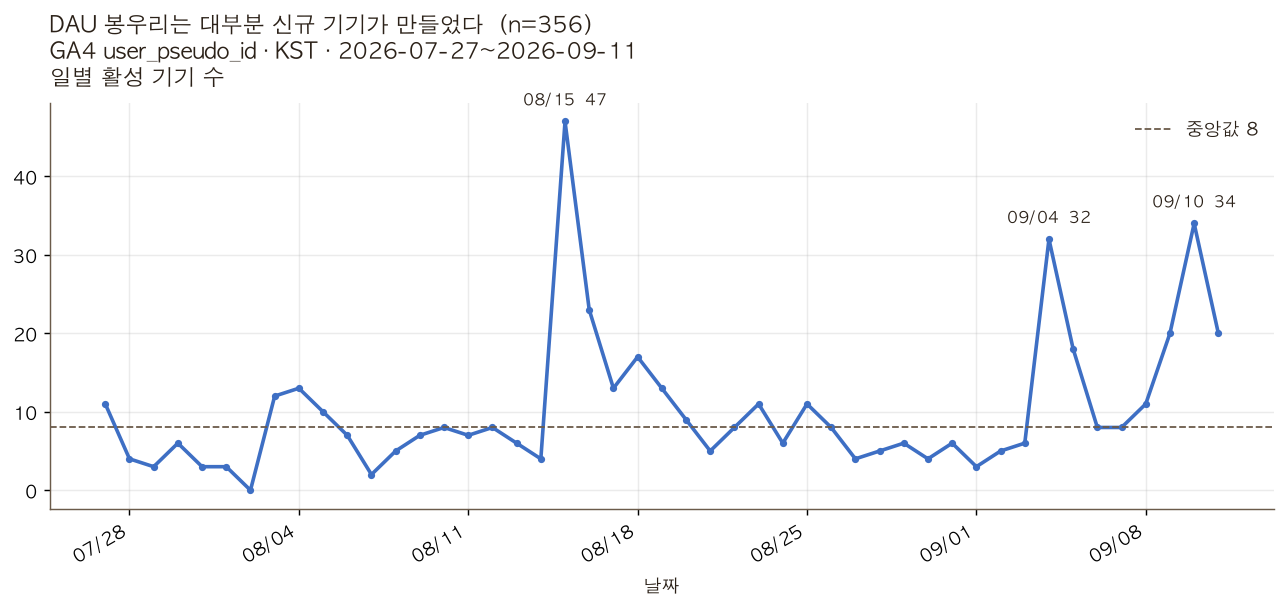

In [4]:
charts = {}
fig, ax = R.new(
    'DAU 봉우리는 대부분 신규 기기가 만들었다', 356,
    sub='GA4 user_pseudo_id · KST · 2026-07-27~2026-09-11',
    ylab='일별 활성 기기 수', figsize=(10, 4.8),
)
ax.plot(daily.day, daily.dau, color=R.PALETTE[1], linewidth=2, marker='o', markersize=3)
ax.axhline(daily.dau.median(), color=R.MUTED, linestyle='--', linewidth=1,
           label=f"중앙값 {daily.dau.median():.0f}")
for _, row in daily.nlargest(3, 'dau').iterrows():
    ax.annotate(f"{row.day:%m/%d}  {row.dau}", (row.day, row.dau),
                xytext=(0, 9), textcoords='offset points', ha='center', fontsize=9)
ax.legend(frameon=False)
ax.set_xlabel('날짜')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
fig.autofmt_xdate(rotation=30, ha='right')
fig.tight_layout()
charts['dau'] = R.save(fig, ax, 'g2_dau_trend')
print(R.check(charts['dau']))
display(R.show(charts['dau']))

## 5. WAU와 28일 MAU

최근 완전 일자인 9월 11일은 **DAU 20 · WAU 85 · 28일 MAU 290**이다. WAU는 8월 21일 115까지 올랐다가 9월 2일 27로 내려갔고, 9월 초 신규 유입 봉우리 뒤 100까지 회복했다. MAU는 완전 창이 20개뿐이라 장기 추세로 부르기 이르다.

g2_wau_mau_trend.png  1287x611px


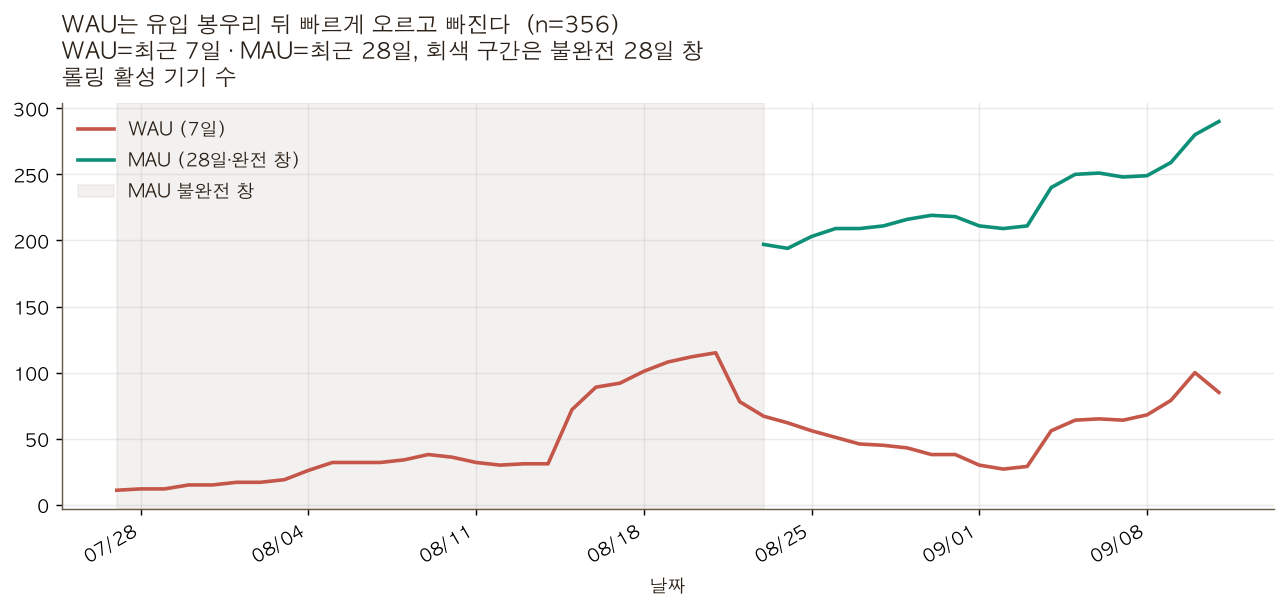

In [5]:
fig, ax = R.new(
    'WAU는 유입 봉우리 뒤 빠르게 오르고 빠진다', 356,
    sub='WAU=최근 7일 · MAU=최근 28일, 회색 구간은 불완전 28일 창',
    ylab='롤링 활성 기기 수', figsize=(10, 4.8),
)
ax.plot(daily.day, daily.wau, label='WAU (7일)', color=R.PALETTE[0], linewidth=2)
complete = daily[daily.complete_28d]
ax.plot(complete.day, complete.mau_28d, label='MAU (28일·완전 창)',
        color=R.PALETTE[2], linewidth=2)
ax.axvspan(daily.day.min(), complete.day.min(), color='#D9D2CA', alpha=.3,
           label='MAU 불완전 창')
ax.legend(frameon=False, loc='upper left')
ax.set_xlabel('날짜')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
fig.autofmt_xdate(rotation=30, ha='right')
fig.tight_layout()
charts['rolling'] = R.save(fig, ax, 'g2_wau_mau_trend')
print(R.check(charts['rolling']))
display(R.show(charts['rolling']))

## 6. 신규와 재방문 구성 — H1 판정

활동일의 **신규 비중 중앙값은 71.8%**, 신규가 재방문보다 큰 날은 **35/46일(76.1%)**이다. 사전 기준인 50%와 70%를 모두 넘으므로 **H1을 채택**한다.

다만 “신규 유입이 중요하다”는 결론이지 “획득 활동이 성공적이다”라는 뜻은 아니다. 전체 356대 중 관측일이 2일 이상인 기기는 39대(11.0%)뿐이다. 유입 봉우리가 활성 규모를 만들지만, 그만큼 오래 남는 구조는 아직 보이지 않는다.

,criterion,observed,pass
0,신규 비중 중앙값 > 50%,71.8%,True
1,신규 > 재방문인 활동일 비율 ≥ 70%,35/46 (76.1%),True


H1 판정: 채택


g2_new_returning_daily.png  1287x611px


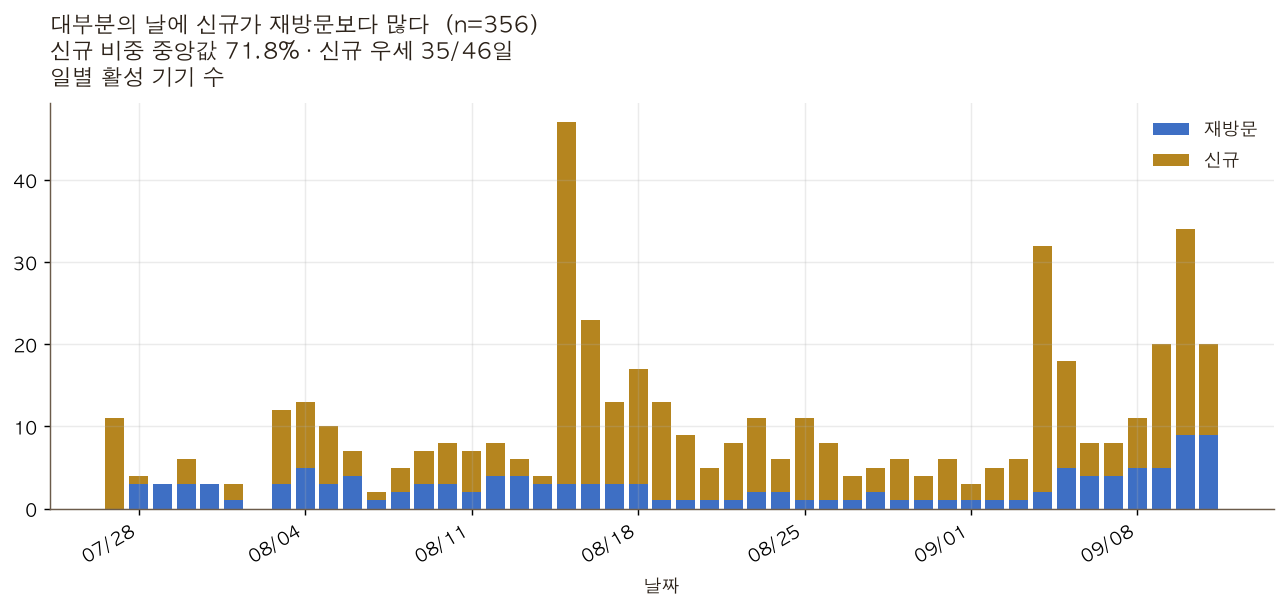

In [6]:
active_days = daily[daily.dau > 0].copy()
active_days['new_share'] = active_days.new_dau / active_days.dau
median_new_share = active_days.new_share.median()
new_majority_days = int((active_days.new_dau > active_days.returning_dau).sum())
new_majority_share = new_majority_days / len(active_days)
h1_pass = median_new_share > .50 and new_majority_share >= .70

h1_table = pd.DataFrame({
    'criterion': ['신규 비중 중앙값 > 50%', '신규 > 재방문인 활동일 비율 ≥ 70%'],
    'observed': [f'{median_new_share:.1%}', f'{new_majority_days}/{len(active_days)} ({new_majority_share:.1%})'],
    'pass': [median_new_share > .50, new_majority_share >= .70],
})
display(h1_table)
print('H1 판정:', '채택' if h1_pass else '기각')

fig, ax = R.new(
    '대부분의 날에 신규가 재방문보다 많다', 356,
    sub=f'신규 비중 중앙값 {median_new_share:.1%} · 신규 우세 {new_majority_days}/{len(active_days)}일',
    ylab='일별 활성 기기 수', figsize=(10, 4.8),
)
ax.bar(daily.day, daily.returning_dau, color=R.PALETTE[1], label='재방문')
ax.bar(daily.day, daily.new_dau, bottom=daily.returning_dau,
       color=R.PALETTE[3], label='신규')
ax.legend(frameon=False)
ax.set_xlabel('날짜')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
fig.autofmt_xdate(rotation=30, ha='right')
fig.tight_layout()
charts['lifecycle'] = R.save(fig, ax, 'g2_new_returning_daily')
print(R.check(charts['lifecycle']))
display(R.show(charts['lifecycle']))

## 7. 고착도(stickiness)

9월 11일 DAU/WAU는 23.5%, DAU/MAU는 6.9%다. 완전 MAU 구간의 일별 DAU/MAU 중앙값은 3.2%다. 이 비율은 “주·월간 도달자 가운데 오늘도 온 비중”이며 리텐션과 같지 않다. 큰 신규 유입 직후에는 분모가 커져 비율이 낮아질 수 있다.

g2_stickiness.png  1287x611px


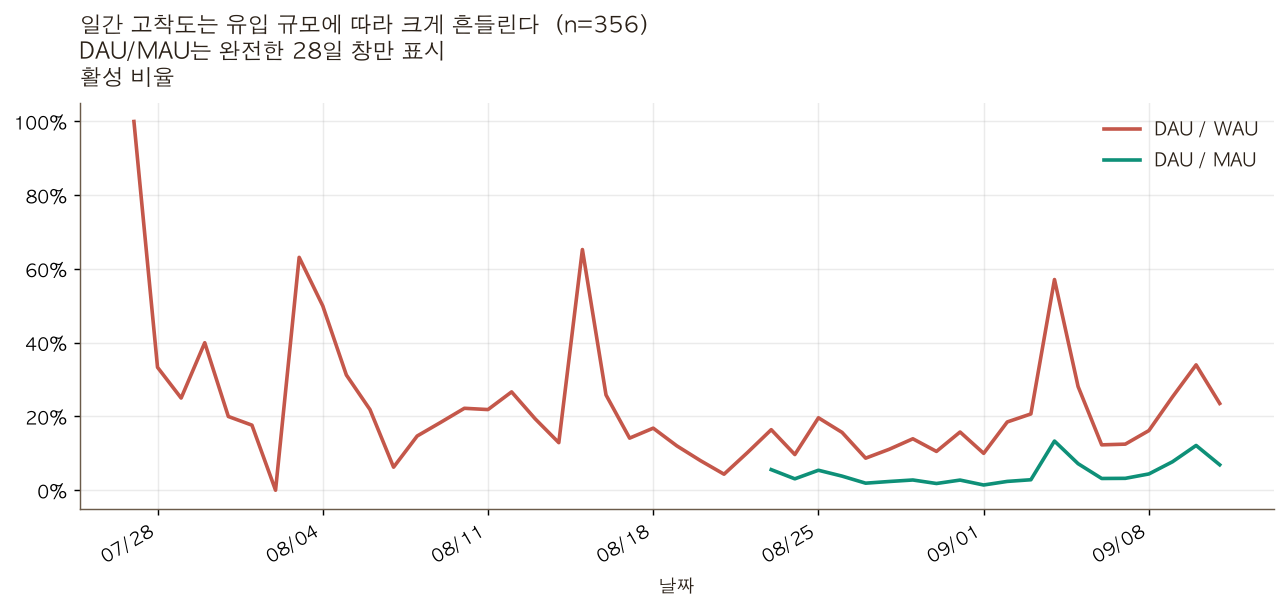

In [7]:
stick = daily.copy()
stick['dau_wau'] = stick.dau / stick.wau
stick['dau_mau'] = np.where(stick.complete_28d, stick.dau / stick.mau_28d, np.nan)
fig, ax = R.new(
    '일간 고착도는 유입 규모에 따라 크게 흔들린다', 356,
    sub='DAU/MAU는 완전한 28일 창만 표시', ylab='활성 비율', figsize=(10, 4.8),
)
ax.plot(stick.day, stick.dau_wau, label='DAU / WAU', color=R.PALETTE[0], linewidth=2)
ax.plot(stick.day, stick.dau_mau, label='DAU / MAU', color=R.PALETTE[2], linewidth=2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(frameon=False)
ax.set_xlabel('날짜')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
fig.autofmt_xdate(rotation=30, ha='right')
fig.tight_layout()
charts['stickiness'] = R.save(fig, ax, 'g2_stickiness', zero_base=True)
print(R.check(charts['stickiness']))
display(R.show(charts['stickiness']))

## 8. 요일

요일마다 관측일이 5~7개뿐이다. 토요일 평균 DAU 14.5는 높아 보이지만 8월 15일의 47대 봉우리가 포함돼 있으며 토요일 중앙값은 6대다. 현재 표본으로 “주말 효과”를 말할 수 없다.

g2_weekday_dau.png  1157x611px


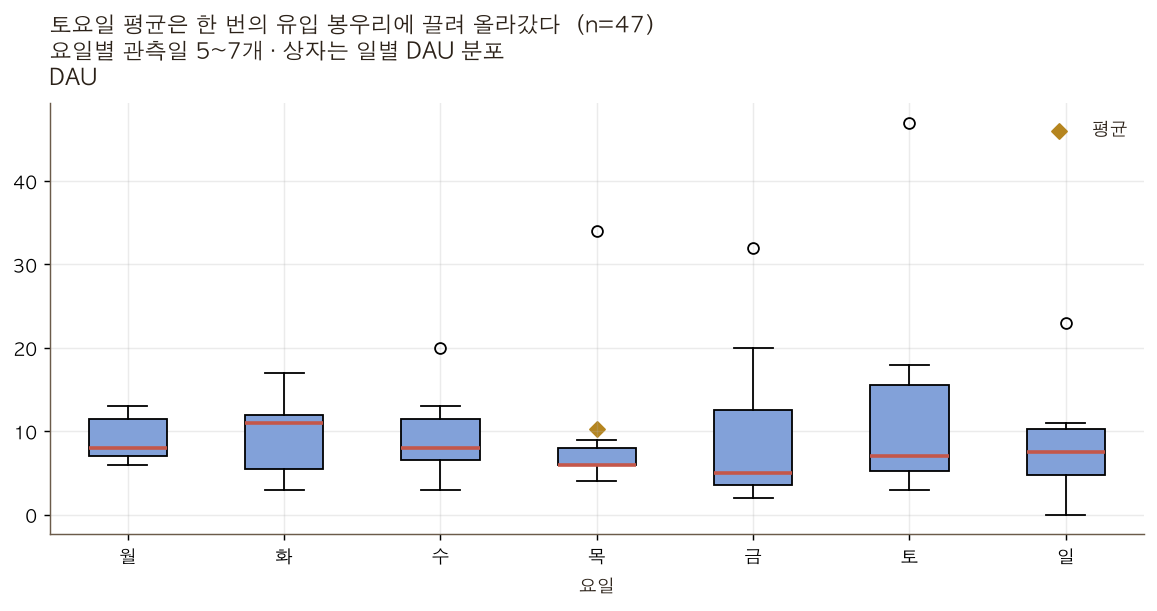

In [8]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily['weekday'] = daily.day.dt.strftime('%a')
values = [daily.loc[daily.weekday == w, 'dau'].to_numpy() for w in weekday_order]
fig, ax = R.new(
    '토요일 평균은 한 번의 유입 봉우리에 끌려 올라갔다', len(daily),
    sub='요일별 관측일 5~7개 · 상자는 일별 DAU 분포', ylab='DAU', figsize=(9, 4.8),
)
bp = ax.boxplot(values, tick_labels=['월','화','수','목','금','토','일'], patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor(R.tint(R.PALETTE[1], .35))
for median in bp['medians']:
    median.set_color(R.PALETTE[0]); median.set_linewidth(2)
ax.scatter(np.arange(1, 8), [np.mean(v) for v in values], color=R.PALETTE[3],
           marker='D', s=35, label='평균')
ax.legend(frameon=False)
ax.set_xlabel('요일')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
charts['weekday'] = R.save(fig, ax, 'g2_weekday_dau')
print(R.check(charts['weekday']))
display(R.show(charts['weekday']))

## 9. 최초 관측 세그먼트

세그먼트는 인과 비교가 아니라 모집단 구성 확인이다. 기기 유형은 데스크톱 205대(57.6%), 모바일 151대(42.4%)다. 국가는 한국 217대(61.0%), 미국 93대(26.1%), 작은 국가를 합친 기타 46대다. 최초 유입은 `(direct)/(none)`이 326대(91.6%)라 획득 경로가 거의 분해되지 않는다.

관측 2일 이상 비율은 한국 18.0%, 미국 0.0%다. 그러나 미국 유입은 특정 날짜의 일회성 봉우리와 겹쳐 있어 국가 자체의 효과로 해석하면 안 된다. 코호트 날짜를 맞춘 리텐션 비교가 다음 질문이다.

g2_device_segments.png  1092x546px


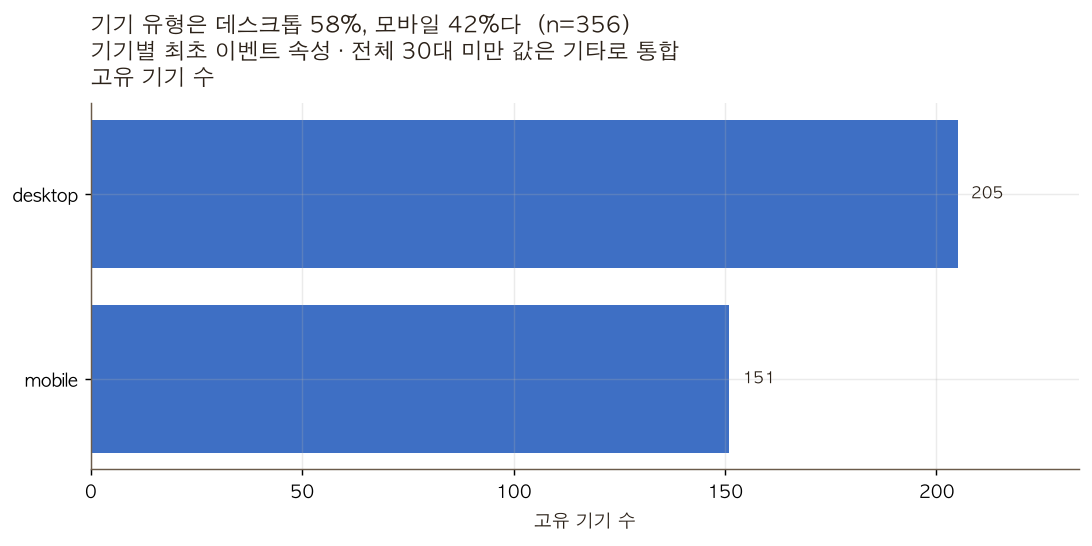

g2_country_segments.png  1092x546px


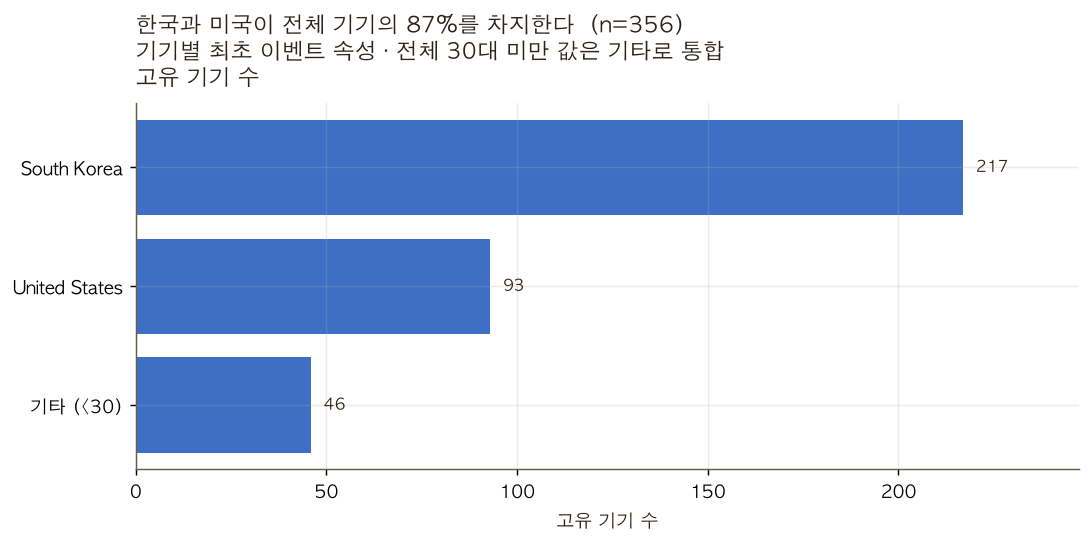

g2_acquisition_segments.png  1092x546px


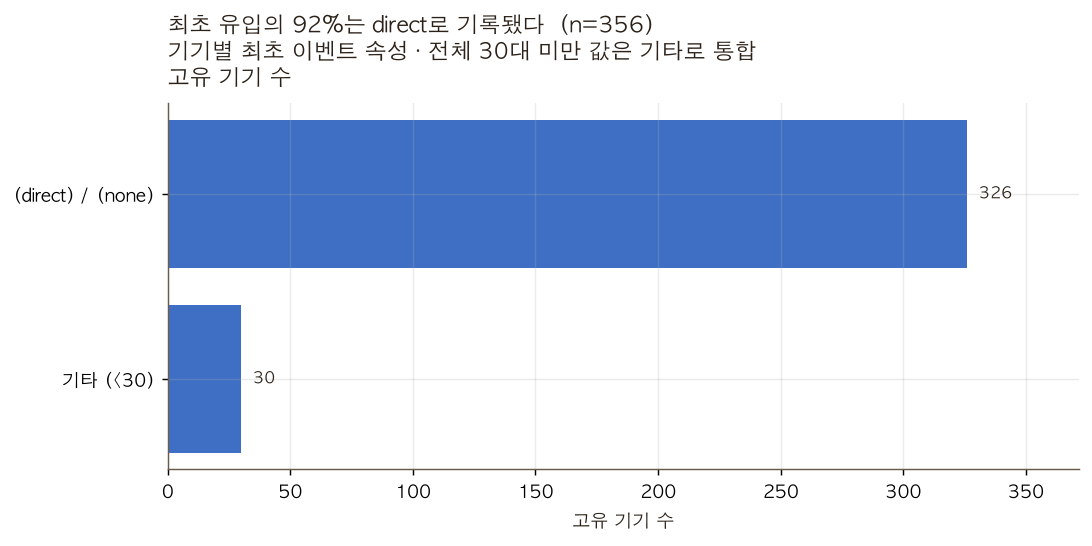

In [9]:
segment_labels = {
    'device': ('기기 유형은 데스크톱 58%, 모바일 42%다', 'g2_device_segments'),
    'country': ('한국과 미국이 전체 기기의 87%를 차지한다', 'g2_country_segments'),
    'acquisition': ('최초 유입의 92%는 direct로 기록됐다', 'g2_acquisition_segments'),
}
for segment_type, (title, filename) in segment_labels.items():
    data = (segment_summary[segment_summary.segment_type == segment_type]
            .sort_values('devices', ascending=True))
    fig, ax = R.new(title, int(data.devices.sum()),
                    sub='기기별 최초 이벤트 속성 · 전체 30대 미만 값은 기타로 통합',
                    ylab='고유 기기 수', figsize=(8.5, 4.3))
    bars = ax.barh(data.segment_value, data.devices, color=R.PALETTE[1])
    for bar, value in zip(bars, data.devices):
        ax.text(value + max(data.devices) * .015, bar.get_y() + bar.get_height()/2,
                f'{value:,}', va='center', fontsize=9)
    ax.set_xlabel('고유 기기 수')
    ax.set_xlim(0, max(data.devices) * 1.14)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    charts[segment_type] = R.save(fig, ax, filename, zero_base=False)
    print(R.check(charts[segment_type]))
    display(R.show(charts[segment_type]))

## 10. 그래서 크기가 얼마나 되나

- 47개 달력일에 356대가 관측됐고, 활동이 발생한 날은 46일이다.
- DAU 중앙값은 8대, 최댓값은 47대다. 최근 7일 평균은 17대로 첫 7일 평균 4.3대보다 높다.
- 최근 완전 일자는 DAU 20 · WAU 85 · 28일 MAU 290이다.
- 신규가 총 356대를 만들었지만 관측 2일 이상인 기기는 39대, 전체의 11.0%다.
- H1은 사전 기준 두 개를 모두 통과했다. 현재 활성 규모는 재방문층보다 신규 유입에 더 민감하다.

## 11. 이 숫자로 말할 수 없는 것

- `user_pseudo_id`는 사람 수가 아니다. 쿠키 삭제와 기기 변경은 신규를 부풀릴 수 있다.
- GA4 이벤트 한 건만 있어도 활성으로 센다. 실제 플레이를 시작한 사용자만 보고 싶다면 핵심 행동 기반 정의가 따로 필요하다.
- 47일은 월간·요일 계절성을 판단하기 짧다. MAU 완전 창도 20개뿐이다.
- 획득 source/medium의 91.6%가 direct라 캠페인 성과를 나누기 어렵다.
- 최초 관측 세그먼트는 날짜·캠페인 구성 차이를 보정하지 않는다. 미국의 0% 재관측을 지역 효과로 해석할 수 없다.
- 베타 유급 테스터와 일반 유입을 GA4만으로 안정적으로 분리할 표식이 없다. 이번 EDA에는 둘이 섞일 수 있다.
- 9월 12일 Supabase에는 활동이 있지만 GA4 일별 export가 미완성이라 이번 추이에서 제외했다.

## 12. 다음에 확인할 것

다음 후보는 **“첫날 핵심 진행 깊이가 D1·D7 재방문을 가른다”**다. 날짜 코호트를 맞추고, 단순 페이지 방문과 실제 게임 행동을 분리한 뒤 검정해야 한다. 이 노트북에서는 모델링이나 다음 가설 검정을 시작하지 않는다.

## 13. W&B 실행 기록

집계표와 PNG만 올린다. 사용자 식별자는 업로드하지 않는다. 같은 노트북을 다시 실행하면 기존 run을 이어 쓴다.

In [10]:
run_file = OUT / 'wandb_run_id.txt'
image_log = {name: tracking.wandb.Image(str(path)) for name, path in charts.items()}
run_kwargs = dict(project=tracking.PROJECT)
if run_file.exists():
    run_kwargs.update(id=run_file.read_text().strip(), resume='must')
else:
    run_kwargs.update(name='g2-activity-eda', tags=['gate', 'eda'])

with tracking.wandb.init(**run_kwargs) as run:
    run.summary['devices'] = 356
    run.summary['calendar_days'] = len(daily)
    run.summary['active_days'] = len(active_days)
    run.summary['latest_dau'] = int(daily.iloc[-1].dau)
    run.summary['latest_wau'] = int(daily.iloc[-1].wau)
    run.summary['latest_mau_28d'] = int(daily.iloc[-1].mau_28d)
    run.summary['median_new_share'] = float(median_new_share)
    run.summary['new_majority_day_share'] = float(new_majority_share)
    run.summary['h1_result'] = 'accepted' if h1_pass else 'rejected'
    run.log(image_log)
    artifact = tracking.wandb.Artifact('g2-activity-eda', type='analysis')
    for csv_path in OUT.glob('*.csv'):
        artifact.add_file(str(csv_path))
    for sql_name in sql_files:
        artifact.add_file(str(SQL / sql_name), name=f'sql/{sql_name}')
    for chart_path in charts.values():
        artifact.add_file(str(chart_path), name=f'figs/{chart_path.name}')
    run.log_artifact(artifact)
    run_file.write_text(run.id, encoding='utf-8')
    print('W&B run:', run.url)
    print('W&B run id:', run.id)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: icucheol to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run r9pzu4by


wandb: Tracking run with wandb version 0.28.2


wandb: Run data is saved locally in /Users/uicheol_hwang/calm_forest/wandb/run-20260912_200044-r9pzu4by
wandb: Run `wandb offline` to turn off syncing.


...

wandb: uploading artifact g2-activity-eda; uploading media/images/dau_0_e7ba4b661dd91f3702b7.png; uploading media/images/weekday_0_70a08d55ebaa75cfa008.png; uploading media/images/country_0_392db6907e99fd652d41.png; uploading media/images/acquisition_0_a4e960c2939b7ce4a154.png (+ 1 more)


wandb: uploading artifact g2-activity-eda


wandb: 
wandb: Run summary:
wandb:            active_days 46
wandb:          calendar_days 47
wandb:                devices 356
wandb:              h1_result accepted
wandb:             latest_dau 20
wandb:         latest_mau_28d 290
wandb:             latest_wau 85
wandb:       median_new_share 0.71825
wandb: new_majority_day_share 0.76087
wandb: 


wandb: 🚀 View run g2-activity-eda at: https://wandb.ai/icucheol/calm-forest/runs/r9pzu4by
wandb: ⭐️ View project at: https://wandb.ai/icucheol/calm-forest
wandb: Synced 4 W&B file(s), 8 media file(s), 17 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260912_200044-r9pzu4by/logs
